<a href="https://colab.research.google.com/github/patriciasandagorda/AST/blob/main/PRACTICA_AST_Clase_6_5B_NPROPHET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 6</h3>
    <h3>Ejercicio B - Prophet & Neural Prophet</h3>
        <p>Docente: Rodrigo Del Rosso, Braian Drago <p>
</div>

# **Clase 6: Redes Neuronales en Series Temporales**

Prophet  o Facebook Prophet (2017) es el predecesor de NeuralProphet (2020)

https://neuralprophet.com/tutorials/index.html

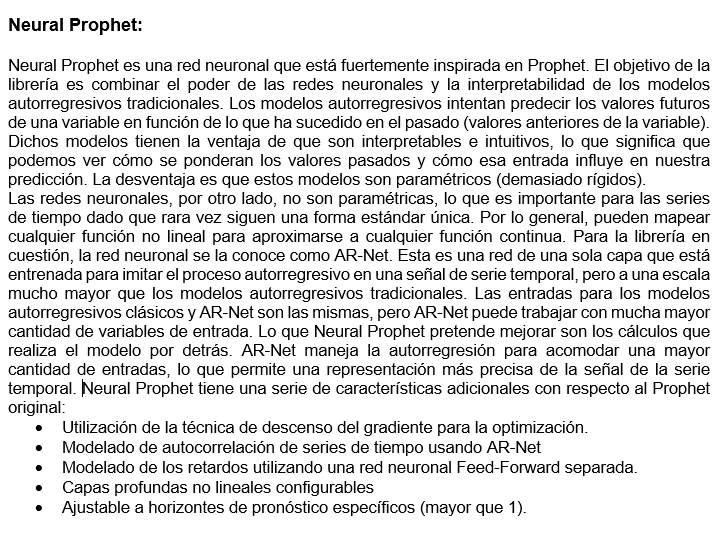

In [ ]:
if "google.colab" in str(get_ipython()):
    # uninstall preinstalled packages from Colab to avoid conflicts
    !pip uninstall -y torch notebook notebook_shim tensorflow tensorflow-datasets prophet torchaudio torchdata torchtext torchvision
    !pip install git+https://github.com/ourownstory/neural_prophet.git # may take a while
    #!pip install neuralprophet # much faster, but may not have the latest upgrades/bugfixes

Found existing installation: torch 2.11.0+cpu
Uninstalling torch-2.11.0+cpu:
  Successfully uninstalled torch-2.11.0+cpu
Found existing installation: notebook 6.5.7
Uninstalling notebook-6.5.7:
  Successfully uninstalled notebook-6.5.7
Found existing installation: notebook_shim 0.2.4
Uninstalling notebook_shim-0.2.4:
  Successfully uninstalled notebook_shim-0.2.4
Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: tensorflow-datasets 4.9.10
Uninstalling tensorflow-datasets-4.9.10:
  Successfully uninstalled tensorflow-datasets-4.9.10
Found existing installation: prophet 1.3.0
Uninstalling prophet-1.3.0:
  Successfully uninstalled prophet-1.3.0
Found existing installation: torchaudio 2.11.0+cpu
Uninstalling torchaudio-2.11.0+cpu:
  Successfully uninstalled torchaudio-2.11.0+cpu
Found existing installation: torchdata 0.11.0
Uninstalling torchdata-0.11.0:
  Successfully uninstalled torchda

In [ ]:
# Se cargan las librerías
from pandas import DataFrame
from pandas import concat
import random
from scipy import stats
import numpy as np
import pandas as pd
from math import sqrt
from numpy import concatenate
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from pandas import DataFrame
from pandas import concat
import seaborn as sn
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import gc
from IPython.display import YouTubeVideo
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
import pandas as pd
from neuralprophet import NeuralProphet, set_log_level

set_log_level("ERROR")

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.1
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.
ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.


In [ ]:
#!pip install optuna

In [ ]:
#import optuna

https://neuralprophet.com/how-to-guides/feature-guides/collect_predictions.html

In [ ]:
# Configurar NeuralProphet para usar Matplotlib
# m.highlight_forecast_step_n = None  # Desactiva interactividad con Plotly
# forecast_plot = m.plot(forecast, plotting_backend="matplotlib")  # Fuerza Matplotlib

In [ ]:
from pandas import DataFrame
from pandas import concat
import random
from scipy import stats
import numpy as np
import pandas as pd
from math import sqrt
from numpy import concatenate
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from pandas import DataFrame
from pandas import concat
import seaborn as sn
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
def cargar_datos():
    url = 'https://raw.githubusercontent.com/braiandrago/AST/main/AirPassengers.csv'
    df = pd.read_csv(url)
    df['Month'] = pd.to_datetime(df['Month'])
    df = df.rename(columns={'Month': 'ds', '#Passengers': 'y'})  #restriccion del modelo, el cambio de nombres
    return df

In [ ]:
df = cargar_datos()
df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [ ]:
# Se define la base de entrenamiento (70%) y testeo (30%)
train = df.iloc[:-24]
test = df.iloc[-24:]
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 120 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      24 non-null     datetime64[ns]
 1   y       24 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 516.0 bytes


In [ ]:
# Se inicializa y entrena el modelo
m = NeuralProphet(n_changepoints=20)
metrics = m.fit(train, freq="MS")

Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr:   0%|          | 0/113 [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

In [ ]:
# Se generan las predicciones
future = m.make_future_dataframe(train,n_historic_predictions=True ,periods=44)
forecast = m.predict(future)

Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
forecast

,ds,y,yhat1,trend,season_yearly
0,1949-01-01,112,94.876862,119.490295,-24.613432
1,1949-02-01,118,89.567535,120.522804,-30.955273
2,1949-03-01,132,123.296684,121.455399,1.841290
3,1949-04-01,129,115.726334,122.487907,-6.761573
4,1949-05-01,121,117.576164,123.487106,-5.910941
...,...,...,...,...,...
159,1962-04-01,None,467.691071,474.670380,-6.979306
160,1962-05-01,None,470.886261,476.615509,-5.729260
161,1962-06-01,None,511.247467,478.625488,32.621944
162,1962-07-01,None,545.692261,480.570648,65.121635


In [ ]:
m.plot(forecast)

In [ ]:
m.plot_components(forecast)

In [ ]:
# Se grafican las predicciones y las componentes
m.plot_parameters()

In [ ]:
# Se generan las predicciones para la base de testeo
X_tst_forecast = m.predict(test);

Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
X_tst_forecast.tail(5)

,ds,y,yhat1,trend,season_yearly
19,1960-08-01,606,496.901245,435.249054,61.652206
20,1960-09-01,508,452.083038,437.259003,14.824029
21,1960-10-01,461,417.089630,439.204132,-22.114525
22,1960-11-01,390,384.551361,441.214081,-56.662727
23,1960-12-01,432,413.375732,443.159241,-29.783493


In [ ]:
m.plot(X_tst_forecast)

In [ ]:
# Cálculo de las medidas de precisión
rmse = sqrt(mean_squared_error(test['y'], X_tst_forecast['yhat1']))
print('Test RMSE: %.3f' % rmse)
mse = mean_squared_error(test['y'], X_tst_forecast['yhat1'])
print('Test MSE: %.3f' % mse)
mae = mean_absolute_error(test['y'], X_tst_forecast['yhat1'])
print('Test MAE: %.3f' % mae)
r2 = r2_score(test['y'], X_tst_forecast['yhat1'])
print('Test R2: %.3f' % r2)

Test RMSE: 49.439
Test MSE: 2444.186
Test MAE: 35.877
Test R2: 0.562


**Y si adicionamos autorregresión?**

In [ ]:
 #21.13 puede pedirle a la var que agregue det cantidad de lags-- para aprender a armar la prediccion con 5 lags elegidos aribitratriamente
 # Se inicializa y entrena el modelo
m = NeuralProphet(growth='linear', n_changepoints=20,n_lags=5)
metrics = m.fit(train, freq="MS")

Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr:   0%|          | 0/113 [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

In [ ]:
# Se generan las predicciones para la base de testeo
X2_tst_forecast = m.predict(test)

Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
X2_tst_forecast

,ds,y,yhat1,ar1,trend,season_yearly
0,1959-01-01,360,NaN,NaN,NaN,NaN
1,1959-02-01,342,NaN,NaN,NaN,NaN
2,1959-03-01,406,NaN,NaN,NaN,NaN
3,1959-04-01,396,NaN,NaN,NaN,NaN
4,1959-05-01,420,NaN,NaN,NaN,NaN
5,1959-06-01,472,454.469452,40.972221,381.075195,32.422039
6,1959-07-01,548,501.814728,53.432816,382.976929,65.404976
7,1959-08-01,559,537.364502,88.164146,384.942017,64.258392
8,1959-09-01,463,497.177460,94.683456,386.907104,15.586880
9,1959-10-01,407,416.497253,49.435341,388.808838,-21.746920


In [ ]:
# Se grafican la base de entrenamiento (punteado negro) y las predicciones (azul)
m.plot(X2_tst_forecast)

Acondicionamiento para cálculo de métricas por los lags:

In [ ]:
lag_tst_forecast=X2_tst_forecast['yhat1'].dropna()

In [ ]:
lag_test = test['y'][5:]

In [ ]:
# Cálculo de las medidas de precisión
rmse = sqrt(mean_squared_error(lag_test, lag_tst_forecast))
print('Test RMSE: %.3f' % rmse)
mse = mean_squared_error(lag_test, lag_tst_forecast)
print('Test MSE: %.3f' % mse)
mae = mean_absolute_error(lag_test, lag_tst_forecast)
print('Test MAE: %.3f' % mae)
r2 = r2_score(lag_test, lag_tst_forecast)
print('Test R2: %.3f' % r2)

Test RMSE: 29.569
Test MSE: 874.317
Test MAE: 24.050
Test R2: 0.835


**Neural Prophet Multivariado**

**Energy price data over the 4 years from Spain**  
Fuente del dataset: https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather

Features:    
*y*: Hourly energy price data    
*temperature*: the extra temperature column

In [ ]:
df = pd.read_csv("https://github.com/ourownstory/neuralprophet-data/raw/main/kaggle-energy/datasets/tutorial04.csv")
df.head()

,ds,y,temperature
0,2015-01-01,64.92,277.00
1,2015-01-02,58.46,277.95
2,2015-01-03,63.35,278.83
3,2015-01-04,50.54,279.64
4,2015-01-05,64.89,279.05


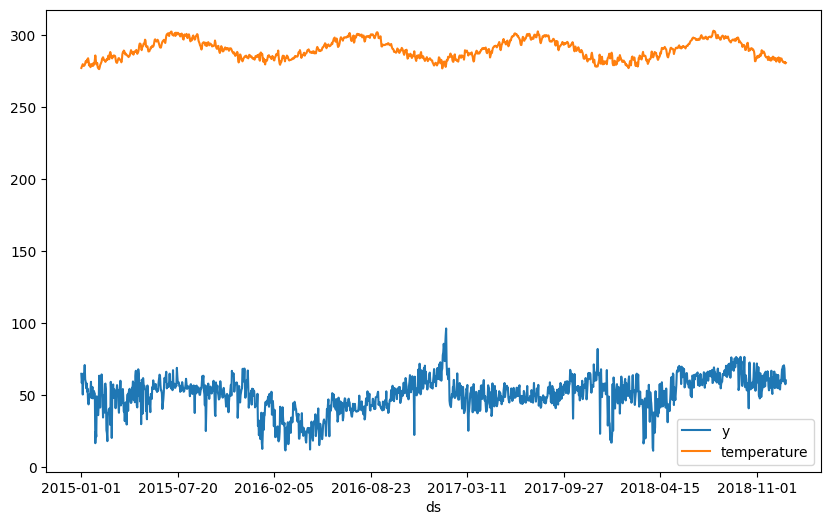

In [ ]:
fig = df.plot(x="ds", y=["y", "temperature"], figsize=(10, 6))

In [ ]:
df_train, df_val = m.split_df(df, valid_p=0.2)

print("Dataset size:", len(df))
print("Train dataset size:", len(df_train))
print("Validation dataset size:", len(df_val))

Dataset size: 1461
Train dataset size: 1170
Validation dataset size: 296


In [ ]:
m = NeuralProphet(
    # Disable trend changepoints
    n_changepoints=10,
    # Disable seasonality components
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    # Add the autogression
    n_lags=10,)

In [ ]:
# Add the new lagged regressor
m.add_lagged_regressor("temperature")   #se indropora la var temperatura como regresora para predecir el consumo de energia 21.14!!!! solo 1 variable regresora
#m.add_lagged_regressor(names="temperature", n_lags=5)

In [ ]:
metrics = m.fit(df_train, validation_df=df_val, progress=True)

Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr:   0%|          | 0/121 [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
metrics

In [ ]:
import matplotlib.pyplot as plt

# Graficar las métricas de entrenamiento y validación
plt.figure(figsize=(12, 6))

# Graficar MAE
plt.subplot(2, 2, 1)
plt.plot(metrics['epoch'], metrics['MAE'], label='Train MAE', color='blue')
plt.plot(metrics['epoch'], metrics['MAE_val'], label='Validation MAE', color='orange')
plt.title('MAE (Mean Absolute Error)')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

In [ ]:
forecast = m.predict(df_val)

Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
m.plot(forecast)

El siguiente gráfico muestra el aporte del regresor "temperature" a la predicción, período a período, a lo largo de la serie temporal.  

*"¿cuándo influyó más/menos la temperatura en mi serie?"*

In [ ]:
m.plot_components(forecast, components=["lagged_regressors"]) #para visualizar la influencia de los regresores rezagados

El siguiente gráfico muestra cómo se distribuye la importancia entre los distintos rezagos (lags) del regresor temperatura, es decir, cuánto pesa la temperatura de "hace 1 período", "hace 2 períodos", etc., sobre el pronóstico.  

*"¿qué tan atrás en el pasado necesito mirar la temperatura para que el modelo funcione bien?"*

In [ ]:
m.plot_parameters(components=["lagged_regressors"])

In [ ]:
metrics

,MAE_val,RMSE_val,Loss_val,RegLoss_val,epoch,MAE,RMSE,Loss,RegLoss,LR
0,80.150452,95.312836,1.364755,0.0,0,104.405128,128.675690,1.336802,0.0,0.005582
1,33.279106,41.367104,0.493579,0.0,1,48.650055,60.205090,0.581876,0.0,0.005819
2,19.229353,23.919779,0.238026,0.0,2,25.048431,32.413723,0.251059,0.0,0.006293
3,13.123638,16.237286,0.132263,0.0,3,15.035131,19.007170,0.123564,0.0,0.007000
4,11.435624,14.478930,0.108299,0.0,4,11.314621,14.083229,0.078663,0.0,0.007934
...,...,...,...,...,...,...,...,...,...,...
105,5.522348,6.942525,0.028150,0.0,105,4.875627,6.542668,0.018589,0.0,0.000630
106,5.418279,6.848944,0.027392,0.0,106,4.885588,6.542335,0.018997,0.0,0.000593
107,5.372626,6.807604,0.027071,0.0,107,4.817935,6.481169,0.018428,0.0,0.000569
108,5.505482,6.926440,0.028021,0.0,108,4.800308,6.512820,0.018328,0.0,0.000556


In [ ]:
metrics_test = m.test(df=df_val)

Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         Loss_test         │    0.02737477608025074    │
│          MAE_val          │     5.414874076843262     │
│         RMSE_val          │     6.846554279327393     │
│       RegLoss_test        │            0.0            │
└───────────────────────────┴───────────────────────────┘